In [1]:
import pandas as pd
import glob

# Combina os arquivos csv de 2010 até 2024 (ignoro o ATP Database por enquanto)
arquivos = sorted(glob.glob("../data/raw/20*.csv"))
df = pd.concat([pd.read_csv(f, low_memory=False) for f in arquivos], ignore_index=True)

df.shape

(42672, 50)

In [2]:
df.shape
df.info()
df.isna().mean().sort_values(ascending=False).head(15)

<class 'pandas.DataFrame'>
RangeIndex: 42672 entries, 0 to 42671
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tourney_id          42672 non-null  str    
 1   tourney_name        42672 non-null  str    
 2   surface             42529 non-null  str    
 3   draw_size           42645 non-null  float64
 4   tourney_level       42672 non-null  str    
 5   indoor              39273 non-null  str    
 6   tourney_date        42672 non-null  int64  
 7   match_num           42672 non-null  int64  
 8   winner_id           42672 non-null  str    
 9   winner_seed         18082 non-null  float64
 10  winner_entry        5546 non-null   str    
 11  winner_name         42672 non-null  str    
 12  winner_hand         42383 non-null  str    
 13  winner_ht           42136 non-null  float64
 14  winner_ioc          42672 non-null  str    
 15  winner_age          42659 non-null  float64
 16  winner_rank    

winner_entry    0.870032
loser_entry     0.791901
loser_seed      0.761436
winner_seed     0.576256
indoor          0.079654
minutes         0.078107
l_bpFaced       0.065570
w_df            0.065570
w_svpt          0.065570
w_1stIn         0.065570
w_1stWon        0.065570
w_2ndWon        0.065570
w_SvGms         0.065570
w_bpSaved       0.065570
w_bpFaced       0.065570
dtype: float64

In [3]:
# Agrupa a proporção de ausentes por torneio. Quero saber se a quantidade de nulos é aleatória ou é maior em torneios alternativos
df['stat_ausente'] = df['w_ace'].isna()
df.groupby('tourney_level')['stat_ausente'].mean().sort_values(ascending=False)
# Confirma a hipótese, os torneios alternativos têm mais ausentes

tourney_level
D      0.638035
O      0.511719
A      0.147793
F      0.066390
250    0.004800
M      0.004000
500    0.003629
G      0.001735
Name: stat_ausente, dtype: float64

In [4]:
# Verifica a proporção de cada torneio. Quero analisar a possibilidade de excluir os torneios alternativos da análise
df['tourney_level'].value_counts(normalize=True).round(3)

tourney_level
250    0.376
M      0.193
G      0.176
500    0.142
D      0.089
A      0.012
O      0.006
F      0.006
Name: proportion, dtype: float64

In [5]:
# Tira as olimpiadas (O) e a copa davis (D): são competições em equipes com regras diferentes dos torneios que quero analisar
# ATP Finals (F) e outros (A) são menos de 2% do dataset, não vão atrapalhar a análise 
df_filtrado = df[~df['tourney_level'].isin(['D', 'O'])].copy()
print(df.shape, "->", df_filtrado.shape)
df_filtrado['w_ace'].isna().mean()

(42672, 51) -> (38609, 51)


np.float64(0.006164365821440597)

In [6]:
df_limpo = df_filtrado.dropna(subset=['w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon', 'l_ace', 'l_df', 'l_svpt', 'l_1stIn', 'l_1stWon', 'l_2ndWon']).copy()
                                        
df_limpo.shape

(38371, 51)

O objetivo das próximas três células é transformar as estatísticas do vencedor e do perdedor em linhas distintas, ficando duas linhas por partida. Assim evito ser tendencioso pro lado do vencedor ao analisar desempenho de saque

In [7]:
colunas_vencedor = ['tourney_id', 'tourney_date', 'surface', 'tourney_level', 'best_of', 'round', 'winner_id', 'winner_name', 'winner_hand', 'winner_ht', 'winner_age', 'winner_rank', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon', 'w_SvGms']

colunas_perdedor = ['tourney_id', 'tourney_date', 'surface', 'tourney_level', 'best_of', 'round', 'loser_id', 'loser_name', 'loser_hand', 'loser_ht', 'loser_age', 'loser_rank', 'l_ace', 'l_df', 'l_svpt', 'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms']

nomes_novos = ['tourney_id', 'tourney_date', 'surface', 'tourney_level', 'best_of', 'round', 'player_id', 'player_name', 'hand', 'ht', 'age', 'rank', 'ace', 'df', 'svpt', 'firstIn', 'firstWon', 'secondWon', 'SvGms']

In [8]:
venceu = df_limpo[colunas_vencedor].copy()
venceu.columns = nomes_novos
venceu['venceu_partida'] = 1

perdeu = df_limpo[colunas_perdedor].copy()
perdeu.columns = nomes_novos
perdeu['venceu_partida'] = 0

In [9]:
jogadores = pd.concat([venceu, perdeu], ignore_index=True)
jogadores.shape

(76742, 20)

In [10]:
jogadores['pct_pontos_saque_ganhos'] = (jogadores['firstWon'] + jogadores['secondWon']) / jogadores['svpt'] * 100
jogadores['pct_primeiro_saque_dentro'] = jogadores['firstIn'] / jogadores['svpt'] * 100
jogadores['aces_por_100_saques'] = jogadores['ace'] / jogadores['svpt'] * 100

jogadores[['pct_pontos_saque_ganhos', 'pct_primeiro_saque_dentro', 'aces_por_100_saques']].describe()

,pct_pontos_saque_ganhos,pct_primeiro_saque_dentro,aces_por_100_saques
count,76720.000000,76720.000000,76720.000000
mean,63.650550,61.440140,7.856664
std,9.072954,7.922385,6.216141
min,0.000000,0.000000,0.000000
25%,57.831325,56.250000,3.370787
50%,63.829787,61.538462,6.493506
75%,69.724771,66.666667,10.869565
max,100.000000,108.510638,81.250000


In [11]:
(jogadores['svpt'] == 0).sum()

np.int64(22)

In [12]:
jogadores_validos = jogadores[jogadores['svpt'] > 0].copy()

inconsistentes = jogadores_validos[jogadores_validos['pct_primeiro_saque_dentro'] > 100]
print("Linhas com % de 1º saque > 100%:", len(inconsistentes))
inconsistentes[['player_name', 'tourney_id', 'firstIn', 'svpt', 'pct_primeiro_saque_dentro']].head(10)

Linhas com % de 1º saque > 100%: 1


,player_name,tourney_id,firstIn,svpt,pct_primeiro_saque_dentro
24969,Benoit Paire,2019-7694,51.0,47.0,108.510638


In [13]:
jogadores_final = jogadores_validos[jogadores_validos['pct_primeiro_saque_dentro'] <= 100].copy()
jogadores_final.shape

(76719, 23)

In [14]:
jogadores_final.to_csv("../data/processed/jogadores_saque.csv", index=False)

### Resumo do tratamento
- Exclusão conceitual da Davis Cup e Olimpíadas (equipe)
- Exclusão de 22 partidas sem pontos de saque registrados
- Exclusão de uma partida com inconsistência lógica (>100% primeiro saque)

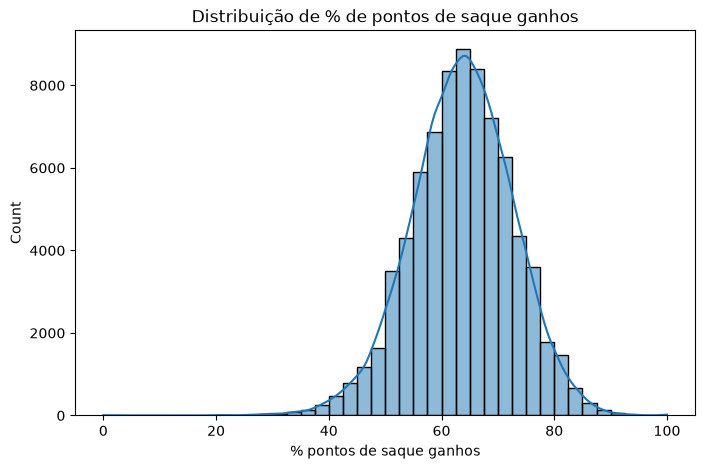

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(jogadores_final['pct_pontos_saque_ganhos'], bins=40, kde=True, ax=ax)
ax.set_title('Distribuição de % de pontos de saque ganhos')
ax.set_xlabel('% pontos de saque ganhos')
plt.show()

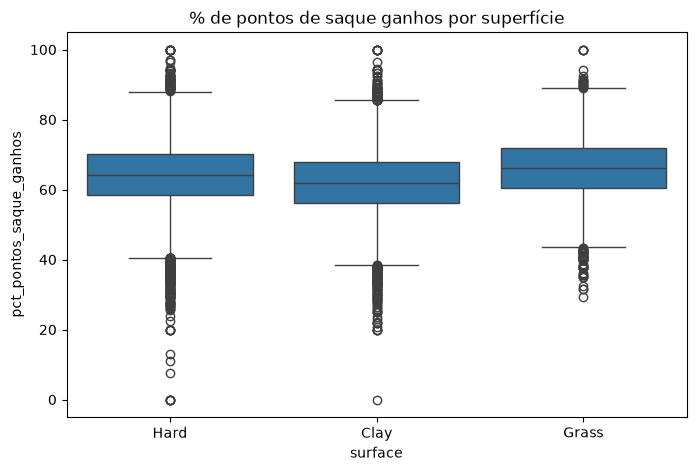

In [16]:
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=jogadores_final, x='surface', y='pct_pontos_saque_ganhos', ax=ax)
ax.set_title('% de pontos de saque ganhos por superfície')
plt.show()

Os gráficos mostraram que há uma concentração que foge da média para baixo na % de saques ganhos. A próxima célula é para verificar se isso tá relacionado com baixo volume de pontos sacados (devido a lesão ou desistência precoce) ou simplesmente baixo desempenho de atletas.

In [17]:
outliers_baixos = jogadores_final[jogadores_final['pct_pontos_saque_ganhos'] < 20]
print("Quantidade:", len(outliers_baixos))
outliers_baixos['svpt'].describe()

Quantidade: 9


count     9.000000
mean      9.111111
std       9.143911
min       1.000000
25%       3.000000
50%       6.000000
75%       9.000000
max      26.000000
Name: svpt, dtype: float64

O primeiro caso se confirmou, definir minimo de pontos sacados resolve o problema

In [18]:
jogadores_final = jogadores_final[jogadores_final['svpt'] >= 20].copy()
jogadores_final.shape

(76410, 23)

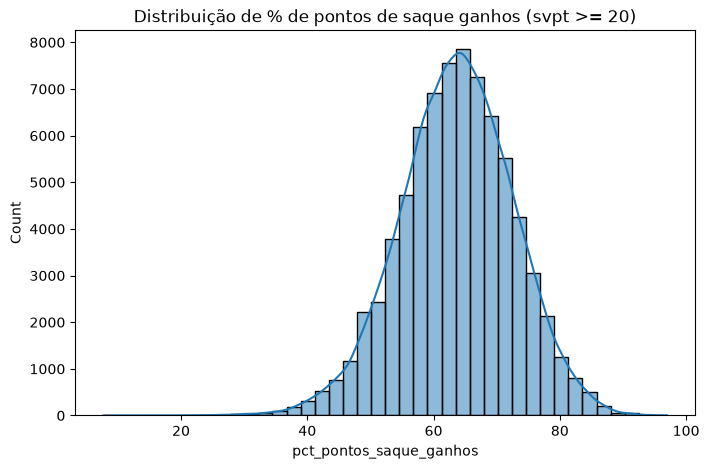

In [19]:
fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(jogadores_final['pct_pontos_saque_ganhos'], bins=40, kde=True, ax=ax)
ax.set_title('Distribuição de % de pontos de saque ganhos (svpt >= 20)')
plt.show()

In [20]:
jogadores_final.to_csv("../data/processed/jogadores_saque.csv", index=False)

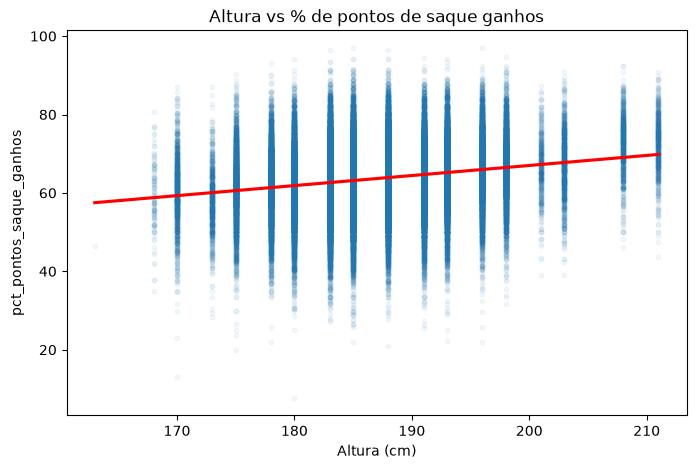

In [21]:
fig, ax = plt.subplots(figsize=(8,5))
sns.regplot(data=jogadores_final, x='ht', y='pct_pontos_saque_ganhos', scatter_kws={'alpha':0.05, 's':10}, line_kws={'color':'red'}, ax=ax)
ax.set_title('Altura vs % de pontos de saque ganhos')
ax.set_xlabel('Altura (cm)')
plt.show()

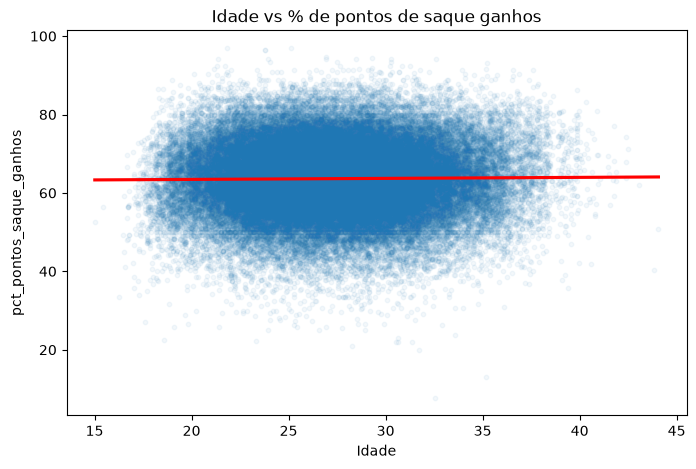

In [22]:
fig, ax = plt.subplots(figsize=(8,5))
sns.regplot(data=jogadores_final, x='age', y='pct_pontos_saque_ganhos', scatter_kws={'alpha':0.05, 's':10}, line_kws={'color':'red'}, ax=ax)
ax.set_title('Idade vs % de pontos de saque ganhos')
ax.set_xlabel('Idade')
plt.show()

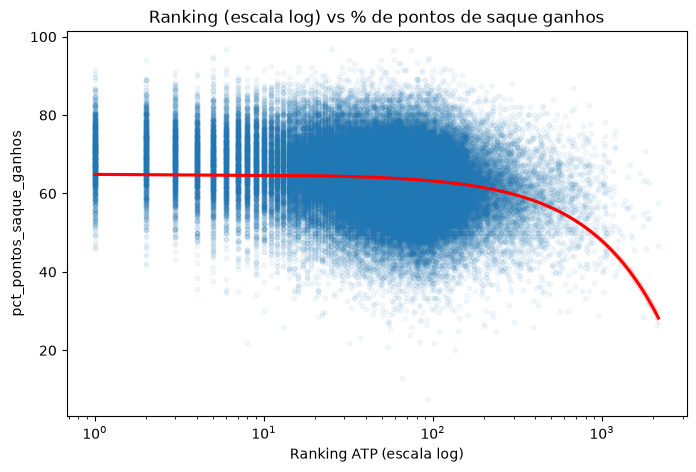

In [23]:
fig, ax = plt.subplots(figsize=(8,5))
sns.regplot(data=jogadores_final, x='rank', y='pct_pontos_saque_ganhos', scatter_kws={'alpha':0.05, 's':10}, line_kws={'color':'red'}, ax=ax)
ax.set_xscale('log')
ax.set_title('Ranking (escala log) vs % de pontos de saque ganhos')
ax.set_xlabel('Ranking ATP (escala log)')
plt.show()

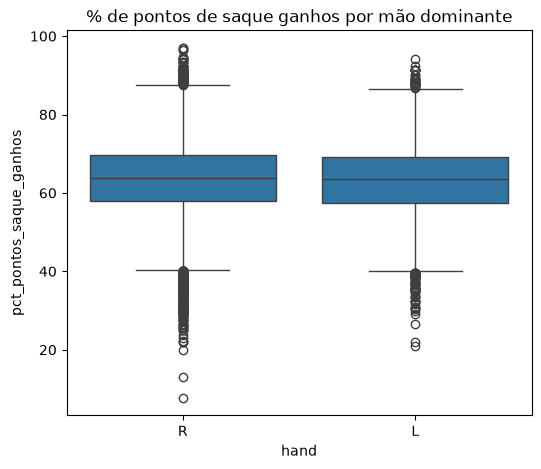

In [24]:
fig, ax = plt.subplots(figsize=(6,5))
sns.boxplot(data=jogadores_final, x='hand', y='pct_pontos_saque_ganhos', ax=ax)
ax.set_title('% de pontos de saque ganhos por mão dominante')
plt.show()